# Lesson 6.1 — The SVD as the Ellipsoid's Anatomy
**Module 6 · Unit 6 · Lesson 21**

J = UΣVᵀ is the ellipse's anatomy: V (joint inputs), Σ (gains/axis lengths), U (tool-space axes), with **J vᵢ = σᵢ uᵢ**. Companion to the *SVD Bars + Condition Number* demo.

In [1]:
import numpy as np
def dh(th,d,a,al):
    ct,st,ca,sa=np.cos(th),np.sin(th),np.cos(al),np.sin(al)
    return np.array([[ct,-st*ca,st*sa,a*ct],[st,ct*ca,-ct*sa,a*st],[0,sa,ca,d],[0,0,0,1]])
def forward_chain(P,T,q):
    M=np.eye(4); Ms=[M.copy()]
    for i,(th0,d0,a,al) in enumerate(P):
        th,d=(th0+q[i],d0) if T[i]=="R" else (th0,d0+q[i]); M=M@dh(th,d,a,al); Ms.append(M.copy())
    return Ms
def geometric_jacobian(P,T,q):
    Ms=forward_chain(P,T,q); on=Ms[-1][:3,3]; J=np.zeros((6,len(q)))
    for i in range(len(q)):
        z=Ms[i][:3,2]; o=Ms[i][:3,3]
        if T[i]=="R": J[:3,i]=np.cross(z,on-o); J[3:,i]=z
        else: J[:3,i]=z
    return J
def Jv_planar(P,T,q): return geometric_jacobian(P,T,q)[:2,:]
P2=[(0,0,1,0),(0,0,1,0)]; T2=["R","R"]
P3=[(0,0,1,0),(0,0,1,0),(0,0,0.6,0)]; T3=["R","R","R"]


## J vᵢ = σᵢ uᵢ : input direction, stretched by its gain, to its output axis

In [2]:
checks=[]
J=Jv_planar(P2,T2,np.array([0.5,0.8])); U,S,Vt=np.linalg.svd(J)
for i in range(2):
    print(f"J v{i+1} =",np.round(J@Vt[i],3),"  sigma{0}*u{0} =".format(i+1),np.round(S[i]*U[:,i],3))
    checks.append(np.allclose(J@Vt[i], S[i]*U[:,i], atol=1e-9))

J v1 = [-1.725  1.14 ]   sigma1*u1 = [-1.725  1.14 ]
J v2 = [0.191 0.29 ]   sigma2*u2 = [0.191 0.29 ]


## The ellipse (image of the unit circle) has axes σᵢ along uᵢ

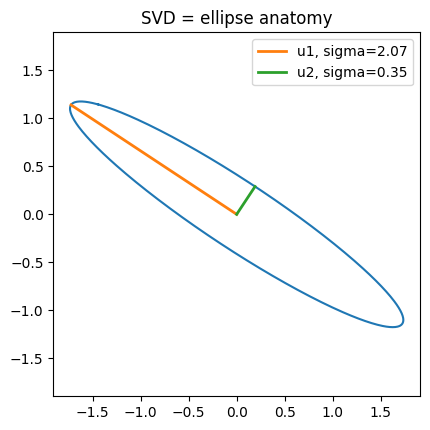

In [3]:
import matplotlib.pyplot as plt
ang=np.linspace(0,2*np.pi,400); ell=J@np.vstack([np.cos(ang),np.sin(ang)])
rad=np.linalg.norm(ell,axis=0)
checks.append(np.isclose(rad.max(),S[0],atol=1e-2) and np.isclose(rad.min(),S[1],atol=1e-2))
plt.figure(figsize=(4.4,4.4)); plt.plot(ell[0],ell[1])
for i in range(2): plt.plot([0,U[0,i]*S[i]],[0,U[1,i]*S[i]],lw=2,label=f'u{i+1}, sigma={S[i]:.2f}')
plt.axis('equal'); plt.legend(); plt.title('SVD = ellipse anatomy'); plt.tight_layout(); plt.show()

## U and V are orthonormal

In [4]:
checks.append(np.allclose(U@U.T,np.eye(2),atol=1e-9) and np.allclose(Vt@Vt.T,np.eye(2),atol=1e-9))
print("U,V orthonormal:",checks[-1])
assert all(checks), f"FAILED: {checks}"
print("All checks passed.")

U,V orthonormal: True
All checks passed.
